# 02 — PDE10A EDA & Baseline Models

**Dataset**: 1162 PDE10A inhibitors with pIC50 values  
**Focus**: EDA (pIC50 distribution, binding modes, temporal coverage, split strategies); then baseline ML models across all 7 pre-defined split strategies (temporal 2011–2013, 3 chemotype-based, random).  
**Reuses**: `src.splitting`, `src.features`, `src.models`, `src.plotting`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.splitting import get_split, list_split_cols, SPLIT_COLS
from src.eda import smiles_validity_report, missing_value_report, max_corr_report
from src.features import morgan_fingerprints, rdkit_descriptors
from src.models import get_baseline_models, evaluate_model
from src.plotting import pred_vs_actual_grid

DATA_PATH = '../data/raw/10822_2022_478_MOESM2_ESM.csv'
SMILES_COL = 'SMILES'
TARGET_COL = 'pic50'
SEED = 42

## Part 1 — Exploratory Data Analysis

### 1.1 Load & Inspect

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head(3)


Shape: (1162, 14)

Columns: ['compound_id', 'SMILES', 'binding_mode_class', 'pic50', 'pic50_date', 'DATESOLVED', 'docking_folder', 'aminohetaryl_c1_amide_split', 'aryl_c1_amide_c2_hetaryl_split', 'temporal_2012_split', 'c1_hetaryl_alkyl_c2_hetaryl_split', 'temporal_2013_split', 'temporal_2011_split', 'random_split']


,compound_id,SMILES,binding_mode_class,pic50,pic50_date,DATESOLVED,docking_folder,aminohetaryl_c1_amide_split,aryl_c1_amide_c2_hetaryl_split,temporal_2012_split,c1_hetaryl_alkyl_c2_hetaryl_split,temporal_2013_split,temporal_2011_split,random_split
0,0,Cn1ncc(C(=O)N2CCC2)c1C(=O)NCCc1nc(-c2cccc(F)c2...,aryl_c1_amide_c2_hetaryl,9.181370,14-Nov-2011,08-Nov-11,5sf8_0,train,test,val,val,train,test,val
1,1,CCN(C)C(=O)c1cnn(C)c1C(=O)Nc1ccn2cc(-c3cccc(OC...,aryl_c1_amide_c2_hetaryl,8.217886,11-Apr-2011,21-Jul-10,5sfr_1,train,test,train,val,train,test,train
2,2,Cn1cncc1Cn1nc(-c2ccccn2)cc1NC(=O)c1nc(C2CC2)cc...,aminohetaryl_c1_amide,8.819874,11-Jan-2010,15-Jun-09,5sf4_2,test,train,train,train,train,train,train


### 1.2 SMILES Validity

In [3]:
report = smiles_validity_report(df, SMILES_COL)
print(f"Valid SMILES:   {report['valid_count']}")
print(f"Invalid SMILES: {report['invalid_count']}")
if report['invalid_indices']:
    print(f"Invalid at indices: {report['invalid_indices']}")


Valid SMILES:   1162
Invalid SMILES: 0


### 1.3 Duplicate Check

In [4]:
from rdkit import Chem

assert report['invalid_count'] == 0, f"Fix {report['invalid_count']} invalid SMILES before canonicalising"

def to_canonical(smi):
    if pd.isna(smi):
        return None
    mol = Chem.MolFromSmiles(str(smi))
    return Chem.MolToSmiles(mol) if mol is not None else None

n_raw_dupes = df[SMILES_COL].duplicated().sum()
canonical = df[SMILES_COL].apply(to_canonical)
n_canon_dupes = canonical.duplicated().sum()

print(f'Raw SMILES duplicates:       {n_raw_dupes}')
print(f'Canonical SMILES duplicates: {n_canon_dupes}')

Raw SMILES duplicates:       0
Canonical SMILES duplicates: 0


### 1.4 pIC50 Distribution

Count:    1162
Mean:     7.288
Std:      1.167
Min/Max:  4.760 / 10.101
Skewness: -0.101
Kurtosis: -0.775


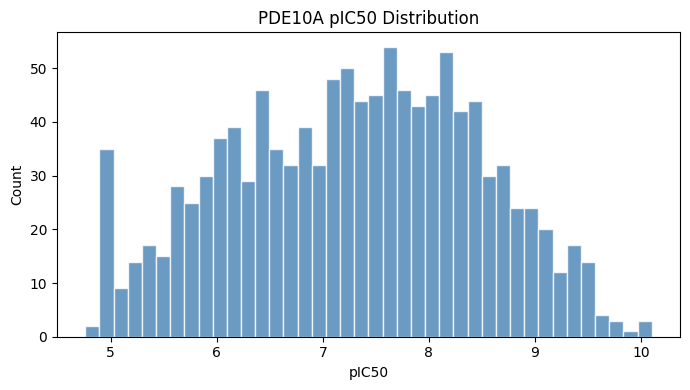

In [5]:
from scipy.stats import skew, kurtosis

pic50 = df[TARGET_COL].dropna()
print(f'Count:    {len(pic50)}')
print(f'Mean:     {pic50.mean():.3f}')
print(f'Std:      {pic50.std():.3f}')
print(f'Min/Max:  {pic50.min():.3f} / {pic50.max():.3f}')
print(f'Skewness: {skew(pic50):.3f}')
print(f'Kurtosis: {kurtosis(pic50):.3f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(pic50, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('pIC50')
ax.set_ylabel('Count')
ax.set_title('PDE10A pIC50 Distribution')
plt.tight_layout()
plt.show()


### 1.4b Maximum Possible Correlation

Upper bound on Pearson r achievable for pIC50 given assay noise (Brown, Muchmore & Hajduk noise model).  
Note: PDE10A has no missing target values, so this uses the full 1162-compound dataset.

In [6]:
mc_report = max_corr_report(df, [TARGET_COL])
mc_report.index = ['pIC50']
print('Maximum possible R² — pIC50 at 2x, 3x, 5x, 10x assay noise (Brown, Muchmore & Hajduk):')
display(mc_report.round(3))

Maximum possible R² — pIC50 at 2x, 3x, 5x, 10x assay noise (Brown, Muchmore & Hajduk):


,n,2-Fold,3-Fold,5-Fold,10-Fold
pIC50,1162,0.938,0.857,0.736,0.577


### 1.5 Outlier Detection

Flag compounds with `pic50` more than 3σ from the mean.  
**Policy**: flag only — no rows removed.  
Note: IQR rule not used here because `pic50` is approximately normally distributed (low skewness); 3σ is the more appropriate criterion for near-normal data.

In [7]:
pic50_vals = df[TARGET_COL]
mu, sigma = pic50_vals.mean(), pic50_vals.std()
mask = (pic50_vals - mu).abs() > 3 * sigma

df['outlier_pic50'] = mask

n_outliers = int(mask.sum())
print(f'3σ outlier count for pic50: {n_outliers} / {len(df)}')
print(f'Bounds: [{mu - 3*sigma:.3f}, {mu + 3*sigma:.3f}]  (mean={mu:.3f}, σ={sigma:.3f})')

if n_outliers:
    display(df[df['outlier_pic50']][['compound_id', 'SMILES', 'pic50', 'binding_mode_class']].reset_index(drop=True))

3σ outlier count for pic50: 0 / 1162
Bounds: [3.786, 10.790]  (mean=7.288, σ=1.167)


### 1.6 Binding Mode Classes

In [ ]:
counts = df['binding_mode_class'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(8, 3))
counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Count')
ax.set_title('Binding Mode Class Counts')
plt.tight_layout()
plt.show()

### 1.7 Temporal Coverage

year
2009    241
2010    453
2011    250
2012    141
2013     73
2014      4
Name: count, dtype: int64


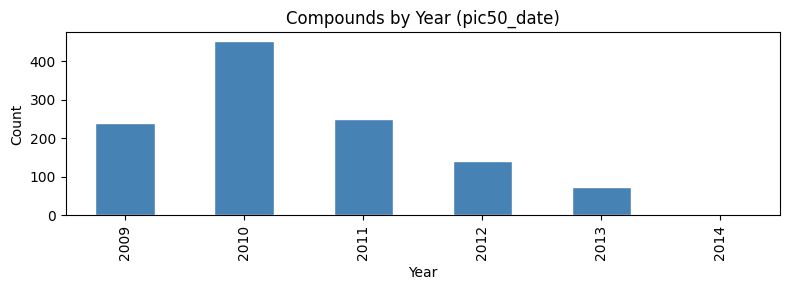

In [9]:
df['year'] = pd.to_datetime(df['pic50_date'], format='%d-%b-%Y').dt.year
year_counts = df['year'].value_counts().sort_index()
print(year_counts)

fig, ax = plt.subplots(figsize=(8, 3))
year_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Compounds by Year (pic50_date)')
plt.tight_layout()
plt.show()


### 1.8 Split Strategy Overview

Each split column assigns rows to `train`, `test`, or `val`. `val` rows and empty rows are excluded from modelling for now see (SYNC-007 synchronizations.md and ADR-003 Decisions.md).

In [10]:
rows_overview = []
for col in SPLIT_COLS:
    vc = df[col].value_counts()
    empty = (df[col] == '').sum() + df[col].isna().sum()
    rows_overview.append({
        'split': col,
        'train': int(vc.get('train', 0)),
        'test': int(vc.get('test', 0)),
        'val': int(vc.get('val', 0)),
        'empty/NaN': int(empty),
    })
split_overview = pd.DataFrame(rows_overview).set_index('split')
display(split_overview)


,train,test,val,empty/NaN
split,,,,
aminohetaryl_c1_amide_split,568,452,141,1
aryl_c1_amide_c2_hetaryl_split,594,419,148,1
temporal_2012_split,848,141,95,78
c1_hetaryl_alkyl_c2_hetaryl_split,696,291,174,1
temporal_2013_split,975,73,109,5
temporal_2011_split,623,250,70,219
random_split,697,233,232,0


### 1.9 Chemical Space

In [11]:
desc = rdkit_descriptors(df[SMILES_COL].tolist())
print(desc.describe().round(2))

ro5_violations = (
    (desc['MW'] > 500).astype(int)
    + (desc['LogP'] > 5).astype(int)
    + (desc['HBD'] > 5).astype(int)
    + (desc['HBA'] > 10).astype(int)
)
print(f'\nLipinski Ro5 — compounds with >=2 violations: {(ro5_violations >= 2).sum()} / {len(desc)}')


            MW     LogP     TPSA      HBD      HBA  RotBonds
count  1162.00  1162.00  1162.00  1162.00  1162.00   1162.00
mean    401.12     2.61   100.05     1.45     7.31      5.42
std      53.05     1.13    27.19     1.09     1.52      1.72
min     255.29    -0.49    30.71     0.00     2.00      1.00
25%     360.39     1.85    79.96     1.00     6.00      4.00
50%     403.45     2.61   101.92     1.00     7.00      5.00
75%     435.22     3.35   118.72     2.00     8.00      7.00
max     717.67     5.82   180.15     5.00    16.00     12.00

Lipinski Ro5 — compounds with >=2 violations: 6 / 1162


### 1.10 EDA Conclusions

- **1162 compounds**, single target (`pic50`), no missing values
- SMILES validity and duplicate counts as printed above
- `pic50` distribution: unimodal, centred ~7–9 (potent PDE10A inhibitors)
- 3 binding mode classes; `aminohetaryl_c1_amide` is the largest group (452 test compounds in its chemotype split), followed by `aryl_c1_amide_c2_hetaryl` (419) and `c1_hetaryl_alkyl_c2_hetaryl` (291)
- Temporal range: 2010–2013; temporal splits reflect this chronology
- `random_split`: most complete (0 empty rows); `temporal_2011_split`: 219 empty rows
- Most compounds satisfy Lipinski Ro5
- 3σ outlier tag added to `df['outlier_pic50']` — see section 1.5

---

## Part 2 — Featurization & Baseline Models

Same 5 models as ADME Phase 1: LinearRegression, BayesianRidge, RandomForest, XGBoost, LightGBM.  
Morgan fingerprints (ECFP4, radius=2, 2048 bits) computed **once** for all 1162 compounds and indexed per split.  
Metrics: R² and RMSE on the `test` partition of each of the 7 split strategies.

### 2.1 Featurize All Compounds (ECFP4)

In [12]:
print('Computing ECFP4 fingerprints for all 1162 compounds...')
X_all = morgan_fingerprints(df[SMILES_COL].tolist())
y_all = df[TARGET_COL].values
print(f'X_all shape: {X_all.shape}')
print(f'y_all shape: {y_all.shape}')


Computing ECFP4 fingerprints for all 1162 compounds...
X_all shape: (1162, 2048)
y_all shape: (1162,)


### 2.2 Build Train/Test Splits

In [13]:
split_data = {}
for split_col in list_split_cols(df):
    train_df, test_df = get_split(df, split_col)
    # df has a clean RangeIndex, so .index values equal positional indices into X_all/y_all
    train_idx = train_df.index.to_numpy()
    test_idx = test_df.index.to_numpy()
    split_data[split_col] = (
        X_all[train_idx],
        X_all[test_idx],
        y_all[train_idx],
        y_all[test_idx],
    )
    print(f'{split_col}: train={len(train_df)}, test={len(test_df)}')

aminohetaryl_c1_amide_split: train=568, test=452
aryl_c1_amide_c2_hetaryl_split: train=594, test=419
temporal_2012_split: train=848, test=141
c1_hetaryl_alkyl_c2_hetaryl_split: train=696, test=291
temporal_2013_split: train=975, test=73
temporal_2011_split: train=623, test=250
random_split: train=697, test=233


### 2.3 Model Training & Evaluation

In [14]:
rows_results = []
preds_store = {}

for split_col, (X_train, X_test, y_train, y_test) in split_data.items():
    preds_store[split_col] = {}
    for name, model in get_baseline_models().items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        preds_store[split_col][name] = (y_test, y_pred)
        metrics = evaluate_model(model, X_test, y_test, y_pred=y_pred)
        rows_results.append({'split': split_col, 'model': name, **metrics})

results_df = pd.DataFrame(rows_results)
print(f'Results: {results_df.shape[0]} rows (expected 35 = 7 splits x 5 models)')
results_df.head(10)

Results: 35 rows (expected 35 = 7 splits x 5 models)


,split,model,R2,RMSE,MSE
0,aminohetaryl_c1_amide_split,LinearRegression,-1.262566e+25,4.027300e+12,1.621915e+25
1,aminohetaryl_c1_amide_split,BayesianRidge,-8.802613e-01,1.554161e+00,2.415417e+00
2,aminohetaryl_c1_amide_split,RandomForest,-4.573633e-01,1.368267e+00,1.872154e+00
3,aminohetaryl_c1_amide_split,XGBoost,-8.244344e-01,1.530915e+00,2.343700e+00
4,aminohetaryl_c1_amide_split,LightGBM,-2.312448e-01,1.257648e+00,1.581679e+00
5,aryl_c1_amide_c2_hetaryl_split,LinearRegression,-8.695375e+24,3.470233e+12,1.204252e+25
6,aryl_c1_amide_c2_hetaryl_split,BayesianRidge,-4.186072e-01,1.401669e+00,1.964677e+00
7,aryl_c1_amide_c2_hetaryl_split,RandomForest,-2.699249e-01,1.326183e+00,1.758762e+00
8,aryl_c1_amide_c2_hetaryl_split,XGBoost,-3.644102e-01,1.374634e+00,1.889618e+00
9,aryl_c1_amide_c2_hetaryl_split,LightGBM,-2.313916e-01,1.305908e+00,1.705396e+00


### 2.4 Results Summary

In [15]:
r2_pivot = results_df.pivot(index='split', columns='model', values='R2').round(3)
rmse_pivot = results_df.pivot(index='split', columns='model', values='RMSE').round(3)

print('R\u00b2 by split and model:')
display(r2_pivot)
print('\nRMSE by split and model:')
display(rmse_pivot)


R² by split and model:


model,BayesianRidge,LightGBM,LinearRegression,RandomForest,XGBoost
split,,,,,
aminohetaryl_c1_amide_split,-0.880,-0.231,-1.262566e+25,-0.457,-0.824
aryl_c1_amide_c2_hetaryl_split,-0.419,-0.231,-8.695375e+24,-0.270,-0.364
c1_hetaryl_alkyl_c2_hetaryl_split,-3.598,-1.900,-7.936894e+24,-1.103,-1.316
random_split,0.587,0.542,-7.846832e+23,0.519,0.583
temporal_2011_split,-0.489,-0.248,-2.244416e+25,-0.307,-0.692
temporal_2012_split,-2.322,-1.753,-3.416794e+25,-1.090,-1.431
temporal_2013_split,0.572,0.323,-4.794402e+24,0.285,0.247



RMSE by split and model:


model,BayesianRidge,LightGBM,LinearRegression,RandomForest,XGBoost
split,,,,,
aminohetaryl_c1_amide_split,1.554,1.258,4.027300e+12,1.368,1.531
aryl_c1_amide_c2_hetaryl_split,1.402,1.306,3.470233e+12,1.326,1.375
c1_hetaryl_alkyl_c2_hetaryl_split,2.444,1.941,3.210305e+12,1.652,1.734
random_split,0.761,0.802,1.049092e+12,0.821,0.765
temporal_2011_split,1.245,1.140,4.833585e+12,1.166,1.327
temporal_2012_split,2.115,1.925,6.781802e+12,1.677,1.809
temporal_2013_split,0.775,0.975,2.594469e+12,1.002,1.028


### 2.5 Cross-Split Comparison

R² per model across all 7 split strategies. Question: does the choice of split inflate or deflate reported R²? Random splits typically give the most optimistic R²; temporal and chemotype splits are harder tests of generalisation.

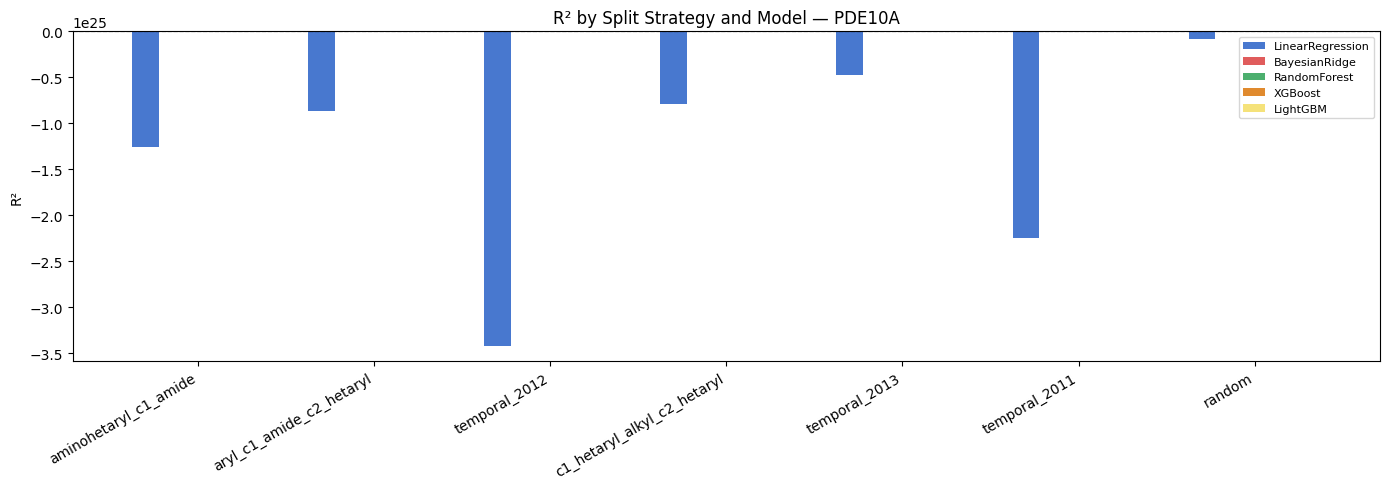

In [16]:
model_names = ['LinearRegression', 'BayesianRidge', 'RandomForest', 'XGBoost', 'LightGBM']
model_colors = {
    'LinearRegression': '#4878cf',
    'BayesianRidge':    '#e05c5c',
    'RandomForest':     '#4caf6e',
    'XGBoost':          '#e08a2e',
    'LightGBM':         '#f5e27a',
}
split_keys = list(split_data.keys())
split_labels = [s.replace('_split', '') for s in split_keys]

x = np.arange(len(split_labels))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(model_names):
    r2_vals = [
        results_df[(results_df['split'] == s) & (results_df['model'] == model)]['R2'].values[0]
        for s in split_keys
    ]
    ax.bar(x + i * width, r2_vals, width, label=model, color=model_colors[model])

ax.set_xticks(x + width * 2)
ax.set_xticklabels(split_labels, rotation=30, ha='right')
ax.set_ylabel('R²')
ax.set_title('R² by Split Strategy and Model — PDE10A')
ax.legend(loc='upper right', fontsize=8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

### 2.6 Predicted vs Actual — all 7 split strategies

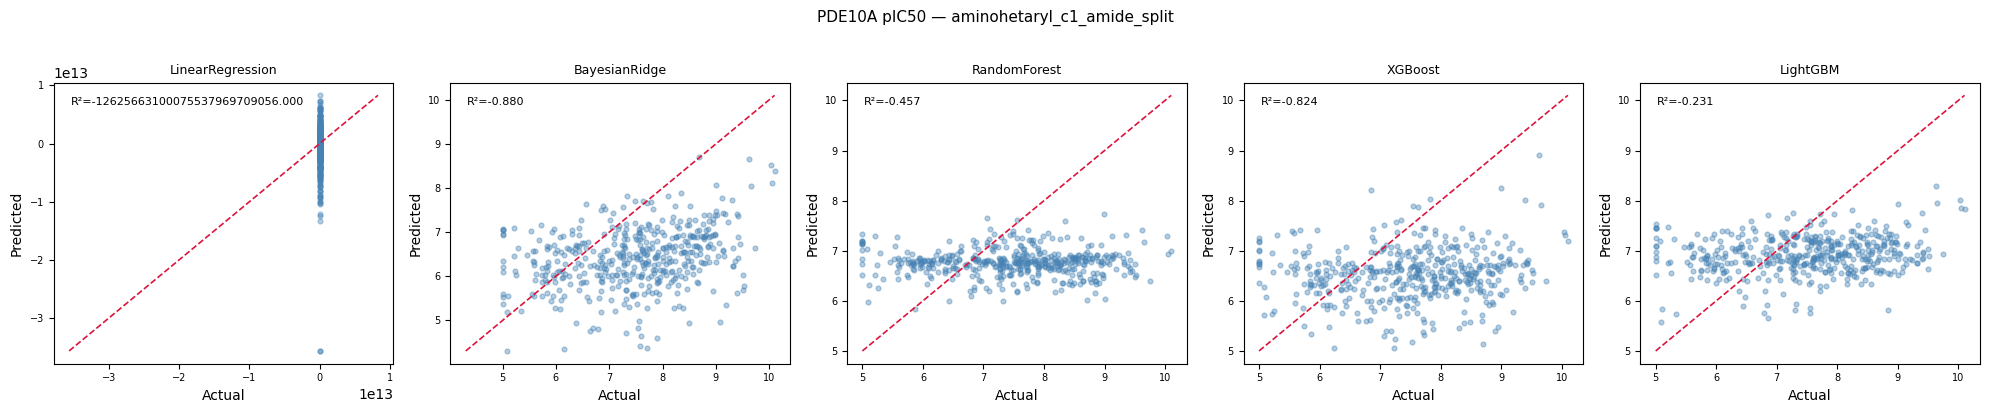

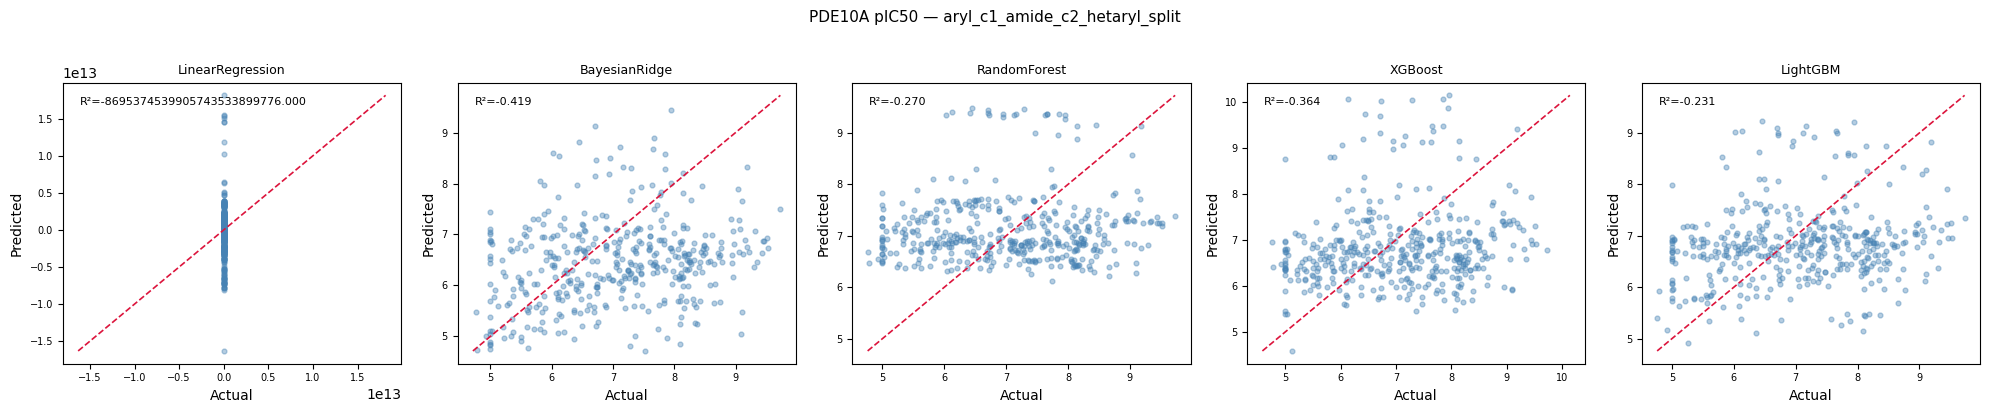

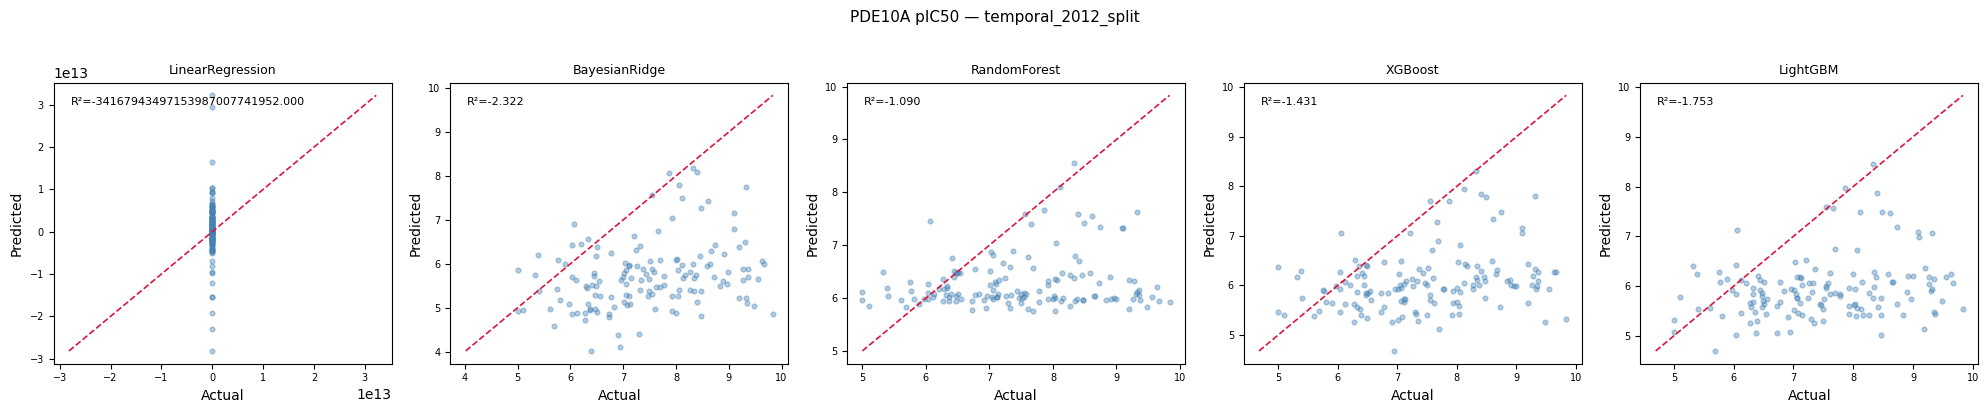

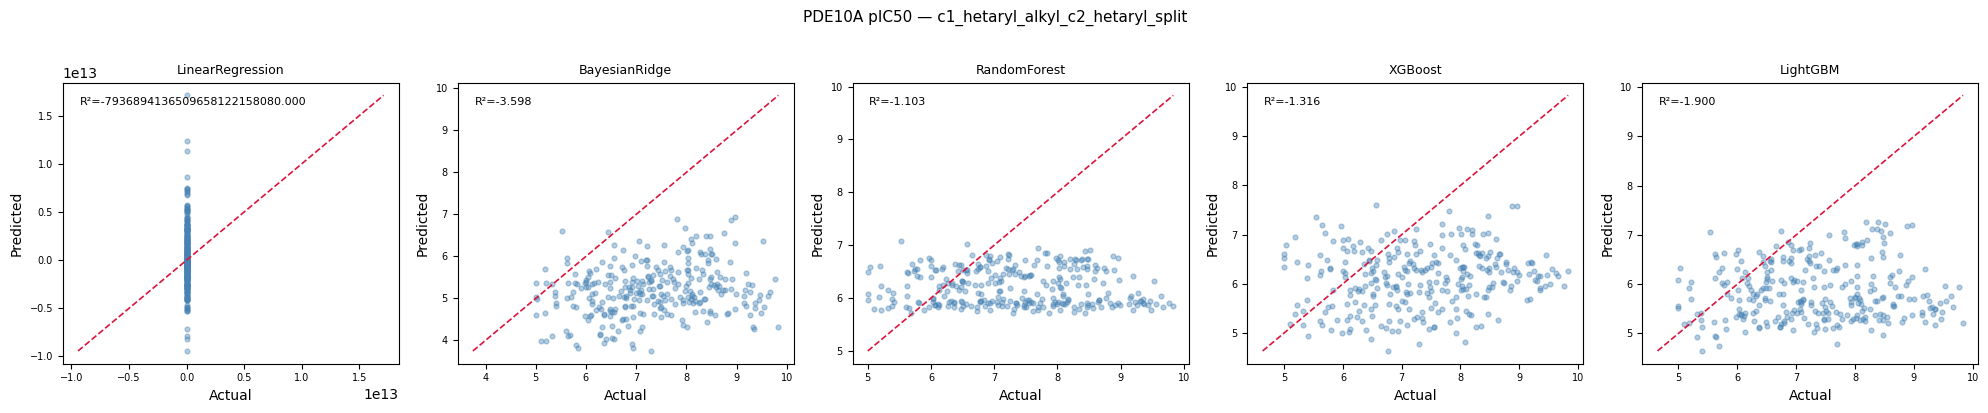

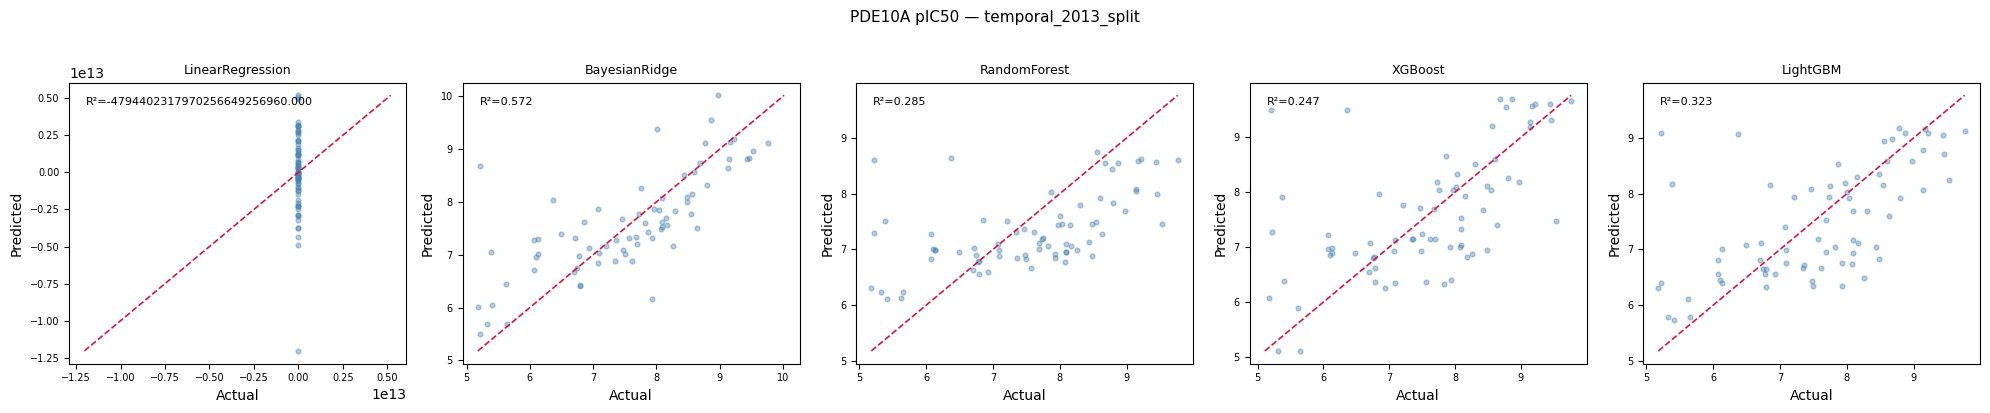

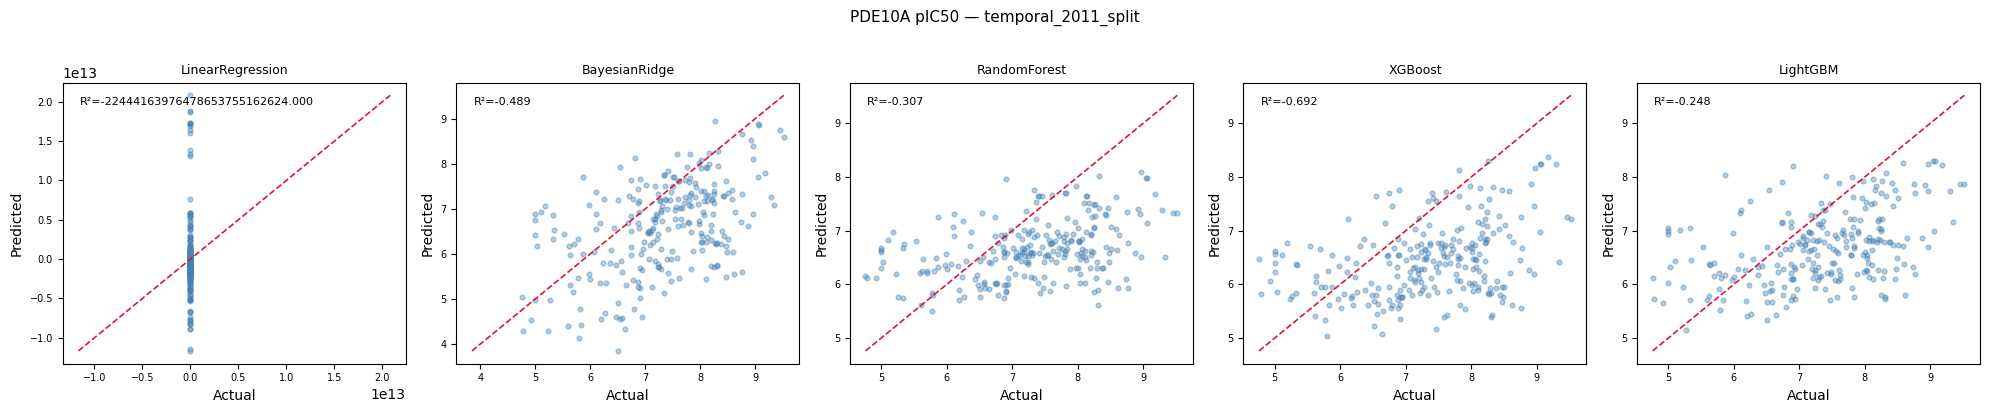

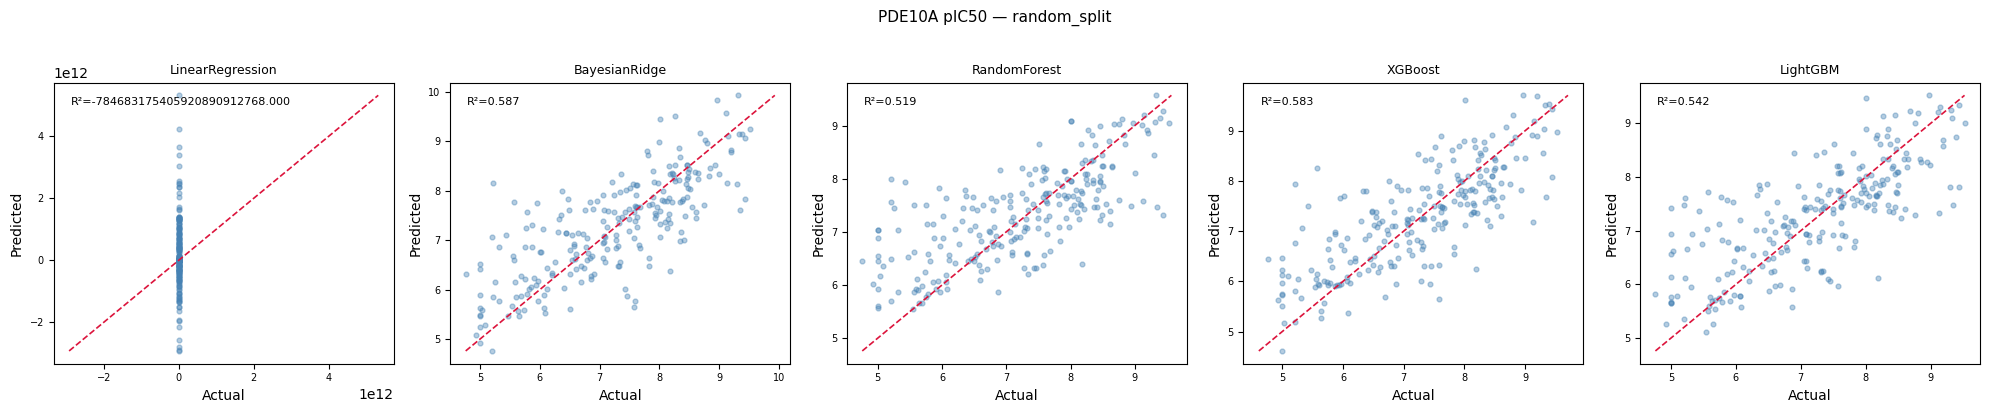

In [17]:
for split_col, preds in preds_store.items():
    fig = pred_vs_actual_grid(
        preds,
        title=f"PDE10A pIC50 — {split_col}"
    )
    plt.show()
